In [ ]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

pd.set_option("display.max_colwidth", 300)
plt.rcParams["figure.figsize"] = (8, 4)


In [2]:
DATA_PATH = "../data/raw/messages.json"

with open(DATA_PATH, encoding="utf-8") as f:
    raw_data = json.load(f)

type(raw_data), raw_data.keys()

(dict, dict_keys(['name', 'type', 'id', 'messages']))

In [3]:
messages = raw_data["messages"]

len(messages), type(messages)

(4596, list)

In [4]:
messages[154]

{'id': 166,
 'type': 'message',
 'date': '2021-09-08T13:54:15',
 'date_unixtime': '1631093055',
 'from': 'معرفی اساتید علموص',
 'from_id': 'channel1558862150',
 'text': ['🧑\u200d🏫 سمانه مشهدی\n🏫 ',
  {'type': 'hashtag', 'text': '#ریاضی'},
  '\n📒 ریاضی۲\n\nمنابع آموزش\n  ┘ از جزوات ترم های گذشته استفاده می کند\n\nحضور و غیاب\n  ┘ حضور مهم نیست اما تاثیر مثبت دارد\n\nمنابع معرفی شده برای امتحان کافی است؟\n  ┘ بله\n\nوضعیت نمره دادن:\n  ┘ منصفانه و هرچی خودت بگیری\n\nارزیابی دانشجو:\n  ┤ پیوستگی و یکپارچگی تدریس: 10\n  ┤ دانش عمومی: 10\n  ┤ توانایی انتقال مطالب و نکات مهم درس: 10\n  ┤ نحوه مدیریت کلاس(نظم و زمان): 10\n  ┤ پاسخگویی(حضوری و غیرحضوری): 9\n  ┤ آداب و رفتار اجتماعی با دانشجویان: 10\n\nراه ارتباطی:\n  ┘ ایمیل و تلگرام\n\nترمی که دانشجو با این استاد کلاس داشته:\n  ┘ بهمن 99\n\nتوضیحات:\n  ┘ بعد از هر مبحث کوییز میگیرن که اگه نمره خوبی کسب نکردید میتونید در میان ترم و پایان ترم اون نمرات رو جبران کنید و اگر نمره خوبی داشتید میتونید در میان ترم و پایان ترم شرکت نکنید و صرفا جمع هم

### Data Record Structure

Each element in the `messages` list represents a single Telegram message published in the “Ostad Elmosi” channel.  
Each message contains metadata such as message ID (`id`), message type (`type`), timestamp (`date`), and sender information.

The main content of each message is stored in the `text` field. However, this field does not have a uniform structure and may consist of a mixture of plain text strings and structured objects such as hashtags, mentions, and URLs. Moreover, not all messages correspond to student evaluations of professors; some messages are purely informational or promotional.

Therefore, extracting structured information related to professors, courses, and student feedback requires a robust parsing strategy based on flexible text patterns rather than simple field extraction.


In [5]:
# Building DataFrame:

df = pd.DataFrame(messages)
df.shape

(4596, 25)

In [6]:
df.columns

Index(['id', 'type', 'date', 'date_unixtime', 'actor', 'actor_id', 'action',
       'title', 'text', 'text_entities', 'from', 'from_id', 'via_bot', 'photo',
       'photo_file_size', 'width', 'height', 'inline_bot_buttons',
       'message_id', 'edited', 'edited_unixtime', 'reactions',
       'reply_to_message_id', 'poll', 'forwarded_from'],
      dtype='object')

In [7]:
# Check the missing data:

df.isna().mean().sort_values(ascending=False)

title                  0.999782
via_bot                0.999782
forwarded_from         0.999565
reply_to_message_id    0.999347
message_id             0.999347
actor_id               0.999130
actor                  0.999130
action                 0.999130
poll                   0.993908
height                 0.938425
width                  0.938425
photo_file_size        0.938425
photo                  0.938425
reactions              0.415796
edited_unixtime        0.367276
edited                 0.367276
inline_bot_buttons     0.069626
from_id                0.000870
from                   0.000870
text                   0.000000
date_unixtime          0.000000
id                     0.000000
type                   0.000000
date                   0.000000
text_entities          0.000000
dtype: float64

### Missing Data Analysis and Feature Selection

The missing value analysis reveals that several fields are only present in specific types of Telegram messages (e.g., system messages, photos, polls, or forwarded content) and are missing in more than 90% of the records. These fields, such as `photo`, `poll`, `forwarded_from`, and `actor`, are not directly related to professor evaluations and will therefore be excluded during the parsing stage.

On the other hand, core fields including `text`, `text_entities`, `date`, and `id` are consistently present across all messages and form the foundation for extracting structured information about professors, courses, and student feedback. Additionally, some fields such as `reactions` and `edited` are treated as optional and will not be used in downstream modeling.


In [9]:
# Apply Normalization on Text: If Text is List => Convert its components to String because of readability without changing or analyzing data.

def normalize_text_for_eda(x):
    if isinstance(x, list):
        return "".join([str(i) for i in x])
    return x

df["text_normalized"] = df["text"].apply(normalize_text_for_eda)

df["text_normalized"].sample(
    min(5, len(df)),
    random_state=42
)

1393    🧑‍🏫 سیاوش کاظمی راد\n🏫 {'type': 'hashtag', 'text': '#مکانیک'}\n📒 مدلسازی حرکات بدن\n\nمنابع آموزش\n  ┘ فایل پاورپوینت یا پی دی اف می دهد\n\nحضور و غیاب\n  ┘ حضور و غیاب نمی کند\n\nمنابع معرفی شده برای امتحان کافی است؟\n  ┘ بله\n\nوضعیت نمره دادن:\n  ┘ دست باز و با ارفاق\n\nارزیابی دانشجو:\n  ┤ پ...
2936    🧑‍🏫 حسینعلی پور\n🏫 {'type': 'hashtag', 'text': '#مکانیک'}\n📒 نیروگاه\n\nمنابع آموزش\n  ┘ در حین تدریس جزوه می نویسیم\n\nحضور و غیاب\n  ┘ حضور مهم است و تاثیر مستقیم دارد\n\nمنابع معرفی شده برای امتحان کافی است؟\n  ┘ بله\n\nوضعیت نمره دادن:\n  ┘ دست باز و با ارفاق\n\nارزیابی دانشجو:\n  ┤ پیوستگی ...
1880    🧑‍🏫 عزیز شیخ علیزاده\n🏫 {'type': 'hashtag', 'text': '#مهندسی_مواد'}\n📒 گارگاه عمومی\n\nمنابع آموزش\n  ┘ منبعی معرفی نمی کنند\n\nحضور و غیاب\n  ┘ حضور مهم است و تاثیر مستقیم دارد\n\nمنابع معرفی شده برای امتحان کافی است؟\n  ┘ خیر\n\nوضعیت نمره دادن:\n  ┘ منصفانه و هرچی خودت بگیری\n\nارزیابی دانشجو...
505     🧑‍🏫 رضا انتظاری ملکی\n🏫 {'type': 'hashtag', 'text': '#برق'}\n📒 مبانی

In [10]:
df["text"].apply(type).value_counts()

text
<class 'list'>    4555
<class 'str'>       41
Name: count, dtype: int64

In [11]:
# Measuring text's length:

df["text_length"] = df["text"].apply(
    lambda x: sum(len(t["text"]) if isinstance(t, dict) else len(t) for t in x)
)

df["text_length"].describe()

count    4596.000000
mean      879.080505
std       267.692240
min         0.000000
25%       754.000000
50%       899.000000
75%      1047.250000
max      1510.000000
Name: text_length, dtype: float64

In [12]:
df.sample(1, random_state=42)["text"].values[0]

['🧑\u200d🏫 سیاوش کاظمی راد\n🏫 ',
 {'type': 'hashtag', 'text': '#مکانیک'},
 '\n📒 مدلسازی حرکات بدن\n\nمنابع آموزش\n  ┘ فایل پاورپوینت یا پی دی اف می دهد\n\nحضور و غیاب\n  ┘ حضور و غیاب نمی کند\n\nمنابع معرفی شده برای امتحان کافی است؟\n  ┘ بله\n\nوضعیت نمره دادن:\n  ┘ دست باز و با ارفاق\n\nارزیابی دانشجو:\n  ┤ پیوستگی و یکپارچگی تدریس: 8\n  ┤ دانش عمومی: 8\n  ┤ توانایی انتقال مطالب و نکات مهم درس: 8\n  ┤ نحوه مدیریت کلاس(نظم و زمان): 8\n  ┤ پاسخگویی(حضوری و غیرحضوری): 10\n  ┤ آداب و رفتار اجتماعی با دانشجویان: 10\n\nراه ارتباطی:\n  ┘ چیزی ندارم\n\nترمی که دانشجو با این استاد کلاس داشته:\n  ┘ بهمن 1400\n\nتوضیحات:\n  ┘ دکتر کاظمی راد به شدت استاد با اخلاق و خوبی هستند. این درسشون با اینکه ترم اولی بود که ارائه می شد خیلی خوب بود و به شدت بازده خوبی داشت. درس پروژه محور هستش و بیشتر نمره رو پروژه ها تشکیل میده. پروژه ها شامل کدنویسی تو متلب (آنالیز گیت)، مدلسازی در OpenSim و بهینه سازی در متلب بود. به شدت به دوستانی که به حرکت شناسی بدن علاقه مند هستند توصیه می\u200cکنم.\n~~~~~~~~~~~~~~~~~

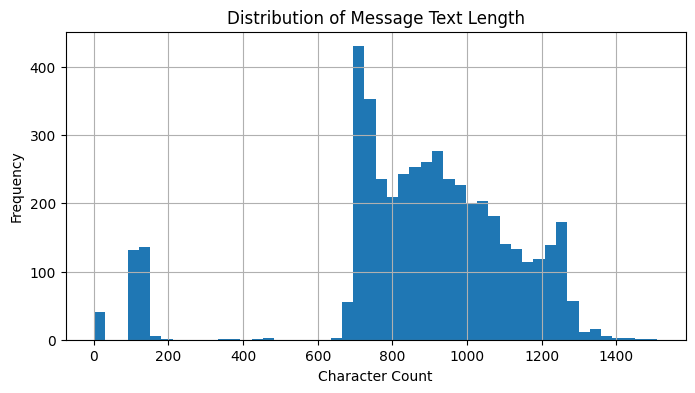

In [13]:
df["text_length"].hist(bins=50)
plt.title("Distribution of Message Text Length")
plt.xlabel("Character Count")
plt.ylabel("Frequency")
plt.show()


## Final EDA Summary:

### Data Quality:

The dataset is noisy and heterogeneous, mainly due to the complex structure of the text field, which contains a mix of plain text, dictionaries (hashtags, mentions), emojis, and inconsistent formatting. Message lengths vary widely, indicating the presence of both short administrative messages and long descriptive reviews.

### Parsing Challenges:

The main challenge in parsing is the lack of a strict and consistent text structure. Although many messages follow similar semantic patterns, variations in formatting, ordering, and language make rule-based extraction non-trivial.

### NLP Suitability:

Despite the noise, the dataset is suitable for NLP tasks, particularly information extraction and classification. However, careful parsing and normalization are required before any modeling can be performed.

### Unreliable Columns:

Several columns contain a high percentage of missing values or provide limited analytical value (e.g., media-related and system fields) and are excluded from further processing. Core fields such as text, text_entities, date, and id are reliable and retained.